## Mockstar position
### Part 1

In [1]:
from scipy.stats import norm
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(42)

N = 5 # number of measurements
mu_true = 1  #true position
sigma = 0.2 # homoscedastic error

error_type = 'heteroscedastic'

if error_type == 'heteroscedastic':
    # Generate the errors in the case of heteroscedastic error
    mu_err = 0.2
    sigma_err = 0.05
    err_process = norm(loc = mu_err, scale = sigma_err)
    sigma = err_process.rvs(size=N)
else:
    sigma = np.array([sigma] * N)

# Assume the underlying process is Gaussian
gaussian_process = norm(loc = mu_true, scale = sigma)

# Generate fake measurements that would be otherwise generated by nature
measurement_data = gaussian_process.rvs(size=N)

Compute the likelihood of each individual measurement and the total

In [2]:
# Assume a reasonable mu interval to test
mu_test = np.linspace(0,2,1000)
# Since we treat each measure as having a Gaussian distribution
# we ask for the PDF at each measurement point assuming each mu_test value
L = np.ones((N, mu_test.size))  # Matrix of ones
for imeas, single_measure in enumerate(measurement_data):
    for imu, single_mu in enumerate(mu_test):
        #L[imeas,imu] = norm.logpdf(single_measure,loc=single_mu,scale=sigma)
        L[imeas,imu] = norm.pdf(single_mu,loc=single_measure,scale=sigma[imeas]) #perché è così??? io avrei invertito

# Compute the total likelihood
#L_total = np.sum(L,0)
L_total = np.prod(L,0) # is tighter so this is the idea of repeating measurements increase estimates

Plot the likelihoods

Text(0.5, 1.0, 'Individual and Total log-$L$ with heteroscedastic error type')

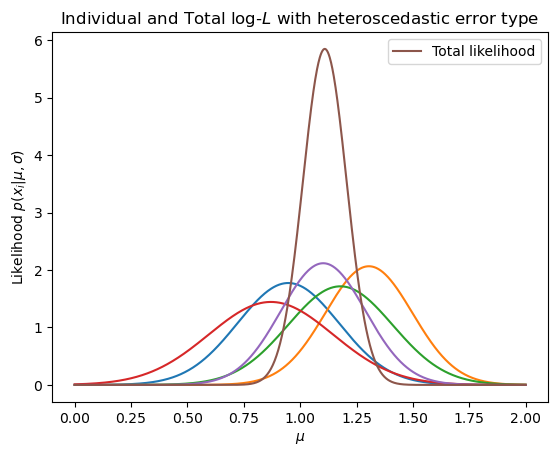

In [3]:
plt.figure()
# Plot each single likelihood        
for sample, l in enumerate(L):
    plt.plot(mu_test,l)
plt.plot(mu_test,L_total,label='Total likelihood')
plt.xlabel('$\mu$')
plt.ylabel('Likelihood $p(x_i|\mu,\sigma)$')
plt.legend()
plt.title(f'Individual and Total log-$L$ with {error_type} error type')

Compute the Maximum Likelihood Estimator and compare it with the theoretical value derived analytically

The maximum likelihood solution is:  1.109109
The maximum likelihood estimator is:  1.1092


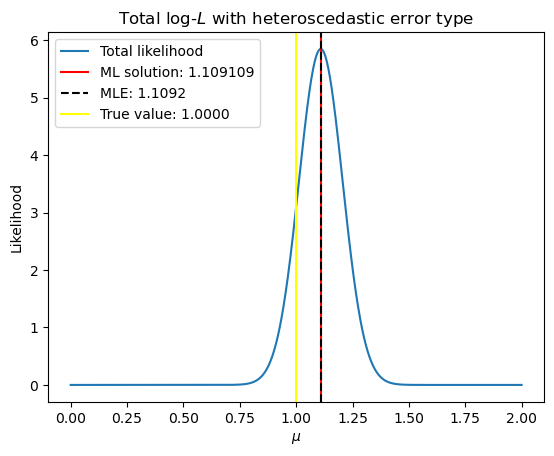

In [6]:
# Compute the MLE from getting the max of the L
IndMuMax = np.argmax(L_total)
MaxLikeSol = mu_test[np.argmax(L_total)]
# Compute the MLE from what expected from a homoscedastic Gaussian
MLE = np.average(measurement_data,axis=0,weights=1/(sigma**2))

plt.figure()
plt.plot(mu_test,L_total,label='Total likelihood')
plt.xlabel('$\mu$')
plt.ylabel('Likelihood')
plt.axvline(MaxLikeSol,c='red', label = f'ML solution: {MaxLikeSol:4f}')
plt.axvline(MLE,c='black',ls='--', label = f'MLE: {MLE:.4f}')
plt.axvline(mu_true,c='yellow', label = f'True value: {mu_true:.4f}')
plt.legend(loc='upper left')
plt.title(f'Total log-$L$ with {error_type} error type')


print(f'The maximum likelihood solution is:  {MaxLikeSol:4f}')
print(f'The maximum likelihood estimator is:  {MLE:.4f}')

### Part 2

Compute the Fischer matrix and covariance from data and comparing it to the theoretical value

In [7]:
Fischer = ((-np.diff(np.log(L_total),2)/(np.diff(mu_test)[0]**2))[IndMuMax])**-1
Covariance = np.sqrt(Fischer)

TheoreticalFisher = -(-np.sum(1/sigma**2))
TheoreticalCovariance = np.sqrt(TheoreticalFisher**-1)
print(f'The computed covariance is:  {Covariance:4f}')
print(f'The theoretical covariance is:  {TheoreticalCovariance:4f}')

The computed covariance is:  0.096927
The theoretical covariance is:  0.096927


Plot the Likelihood and compare it with the model. They have the same profile.

Text(0.5, 1.0, 'Comparison of the computed total likelihood and a Gaussian centred at the MLE')

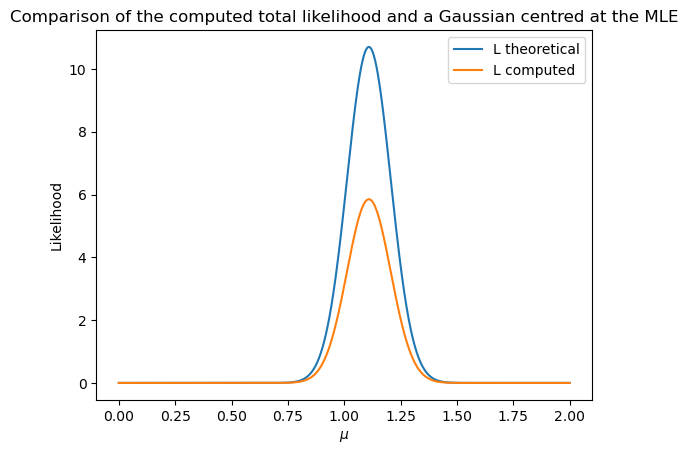

In [8]:
plt.figure()
L_theoretical = norm.pdf(mu_test,loc = MLE, scale = TheoreticalCovariance)
plt.plot(mu_test,2.6*L_theoretical,label='L theoretical')
plt.plot(mu_test,L_total,label='L computed')
plt.xlabel('$\mu$')
plt.ylabel('Likelihood')
plt.legend()
plt.title('Comparison of the computed total likelihood and a Gaussian centred at the MLE')

### Part 3
The code is already generalized with heteroscedastic errors